# Data Preprocessing

In [27]:
from tensorflow.keras import layers
import tensorflow as tf
import os
import matplotlib.pyplot as plt

## LOAD DATASET

In [10]:
path = "../dataset/asl_alphabet_train/asl_alphabet_train"

In [11]:
dataset = tf.keras.utils.image_dataset_from_directory(
    path,
    image_size=(96,96),
    batch_size=32,
    shuffle=True,
    color_mode="grayscale", # Converts the Images to grayscale
)

class_names = dataset.class_names
print("Classes:", class_names)

Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'del', 'nothing', 'space']


In [12]:
for folder in os.listdir(path):
    folder_path = os.path.join(path, folder)

    if os.path.isdir(folder_path):
        num_images = len([
            file for file in os.listdir(folder_path)
            if file.endswith(('.jpg'))
        ])

        print(f"{folder}: {num_images} images")

A: 3000 images
B: 3000 images
C: 3000 images
D: 3000 images
del: 3000 images
E: 3000 images
F: 3000 images
G: 3000 images
H: 3000 images
I: 3000 images
K: 3000 images
L: 3000 images
M: 3000 images
N: 3000 images
nothing: 3000 images
O: 3000 images
P: 3000 images
Q: 3000 images
R: 3000 images
S: 3000 images
space: 3000 images
T: 3000 images
U: 3000 images
V: 3000 images
W: 3000 images
X: 3000 images
Y: 3000 images


## IMAGE VISUALIZATION

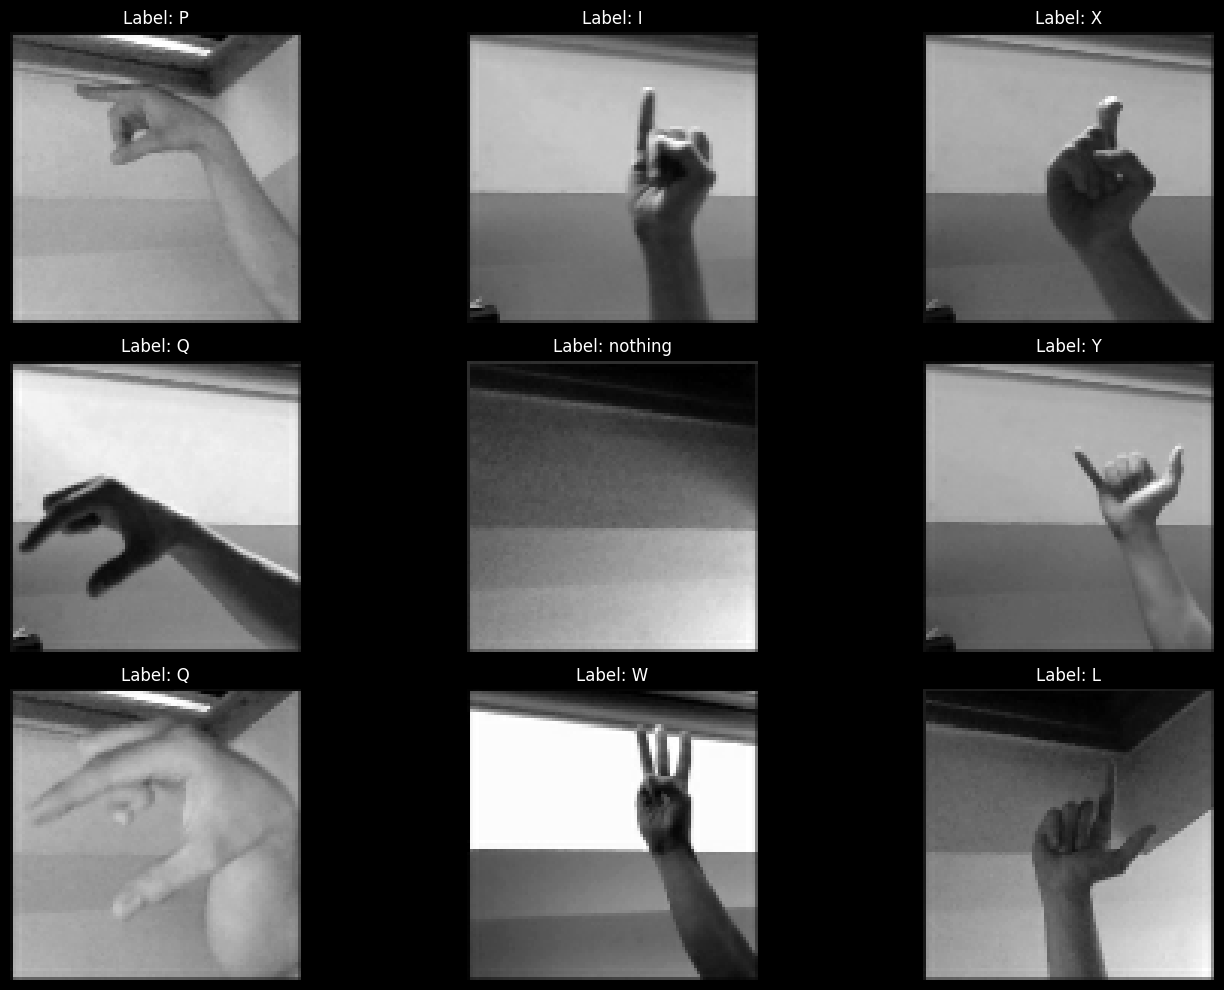

In [13]:
for images, labels in dataset.take(1):
    plt.figure(figsize=(15, 10))

    # Display first 9 images
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"), cmap="gray")
        plt.title(f"Label: {class_names[labels[i]]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

## DATA NORMALIZATION

In [14]:
def normalize(image, labels):
    image = tf.cast(image, tf.float32) / 255.0
    return image, labels

normalized_dataset = dataset.map(normalize)

# Check the first batch
for images, labels in normalized_dataset.take(1):
    print(f"Min value: {tf.reduce_min(images).numpy()}")
    print(f"Max value: {tf.reduce_max(images).numpy()}")
    break

Min value: 0.0
Max value: 1.0


## DATA SPLITTING

In [24]:
data_size = len(normalized_dataset)

train_size = int(0.8 * data_size)
validation_size = int(0.1 * data_size)
test_size = data_size - train_size - validation_size

train_dataset = normalized_dataset.take(train_size)        # 80%
remaining = normalized_dataset.skip(train_size)            # remaining 20%
validation_dataset = remaining.take(validation_size)       # 10%
test_dataset = remaining.take(test_size)                   # 10%

## DATA AUGMENTATION

In [34]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1,0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
])

AUTOTUNE = tf.data.experimental.AUTOTUNE

train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).cache().shuffle(1000).prefetch(buffer_size = AUTOTUNE)

test_dataset = test_dataset.cache().prefetch(buffer_size = AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size = AUTOTUNE)